In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
ref = pd.read_csv('ref.csv',skiprows=33,skipfooter=1,sep=';',names=['lambda','I']).astype(float)
ref_noise = pd.read_csv('ref_noise.csv',skiprows=33,skipfooter=1,sep=';',names=['lambda','I']).astype(float)
m1 = pd.read_csv('m1.csv',skiprows=33,skipfooter=1,sep=';',names=['lambda','I']).astype(float)
m2 = pd.read_csv('m2.csv',skiprows=33,skipfooter=1,sep=';',names=['lambda','I']).astype(float)
m3 = pd.read_csv('m3.csv',skiprows=33,skipfooter=1,sep=';',names=['lambda','I']).astype(float)
m4 = pd.read_csv('m4.csv',skiprows=33,skipfooter=1,sep=';',names=['lambda','I']).astype(float)
m5 = pd.read_csv('m5.csv',skiprows=33,skipfooter=1,sep=';',names=['lambda','I']).astype(float)
m6 = pd.read_csv('m6.csv',skiprows=33,skipfooter=1,sep=';',names=['lambda','I']).astype(float)
m7 = pd.read_csv('m7.csv',skiprows=33,skipfooter=1,sep=';',names=['lambda','I']).astype(float)

m1_noise = pd.read_csv('m1_noise.csv',skiprows=33,skipfooter=1,sep=';',names=['lambda','I']).astype(float)
m2_noise = pd.read_csv('m2_noise.csv',skiprows=33,skipfooter=1,sep=';',names=['lambda','I']).astype(float)
m3_noise = pd.read_csv('m3_noise.csv',skiprows=33,skipfooter=1,sep=';',names=['lambda','I']).astype(float)
m4_noise = pd.read_csv('m4_noise.csv',skiprows=33,skipfooter=1,sep=';',names=['lambda','I']).astype(float)
m5_noise = pd.read_csv('m5_noise.csv',skiprows=33,skipfooter=1,sep=';',names=['lambda','I']).astype(float)
m6_noise = pd.read_csv('m6_noise.csv',skiprows=33,skipfooter=1,sep=';',names=['lambda','I']).astype(float)
m7_noise = pd.read_csv('m7_noise.csv',skiprows=33,skipfooter=1,sep=';',names=['lambda','I']).astype(float)

Ms = [m1,m2,m3,m4,m5,m6,m7]
Ms_noise = [m1_noise,m2_noise,m3_noise,m4_noise,m5_noise,m6_noise,m7_noise]

/tmp/ipykernel_12909/3898041399.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  ref = pd.read_csv('ref.csv',skiprows=33,skipfooter=1,sep=';',names=['lambda','I']).astype(float)
/tmp/ipykernel_12909/3898041399.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  ref_noise = pd.read_csv('ref_noise.csv',skiprows=33,skipfooter=1,sep=';',names=['lambda','I']).astype(float)
/tmp/ipykernel_12909/3898041399.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  m1 = pd.read_csv('m1.csv',skiprows=33,skipfooter=1,sep=';',names=['lambda','I']).astype(float)
/tmp/ipykernel_12909/3898041399.py:4: ParserWarning: Falling back to the 'python' engine because

In [32]:
molar_mass = 319.85 # g/mol
volume = 0.12 # l
initial_mass = 0.016 # g

concentrations = np.array([(initial_mass/molar_mass)/volume,0,0,0,0,0,0]) # M

for i in range(1,7):
    ni = concentrations[i-1]*0.1
    concentrations[i] = ni/volume

concentrations *= 1000 # mM

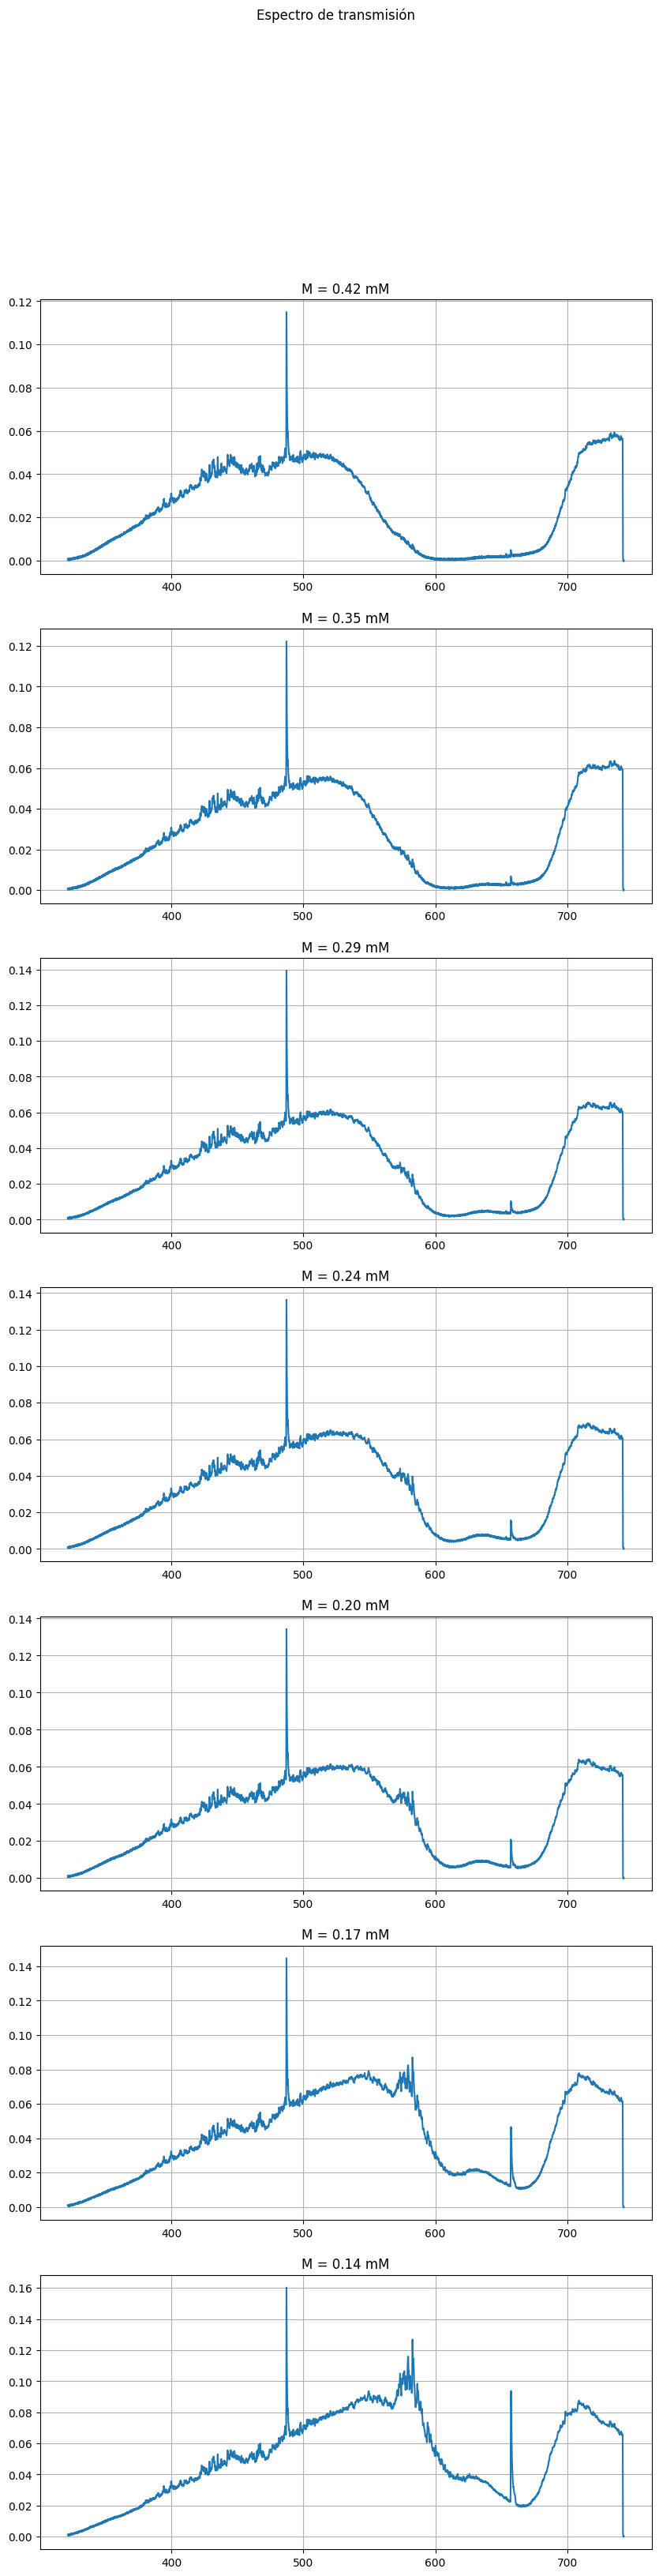

In [49]:
fig, ax = plt.subplots(7,1,figsize=(10,37))
fig.suptitle('Espectro de transmisión')

for i,M in enumerate(Ms):
    ax[i].plot(M['lambda'],M['I'])
    ax[i].set(title=f'M = {concentrations[i]:.2f} mM')
    ax[i].grid()


In [61]:
Ts = [pd.DataFrame() for i in range(7)]
for i,T in enumerate(Ts):
    T['lambda'] = ref['lambda']
    T['T'] = (Ms[i]['I']-Ms_noise[i]['I'])/(ref['I']-ref_noise['I'])
    T['A'] = -np.log10(T['T'])

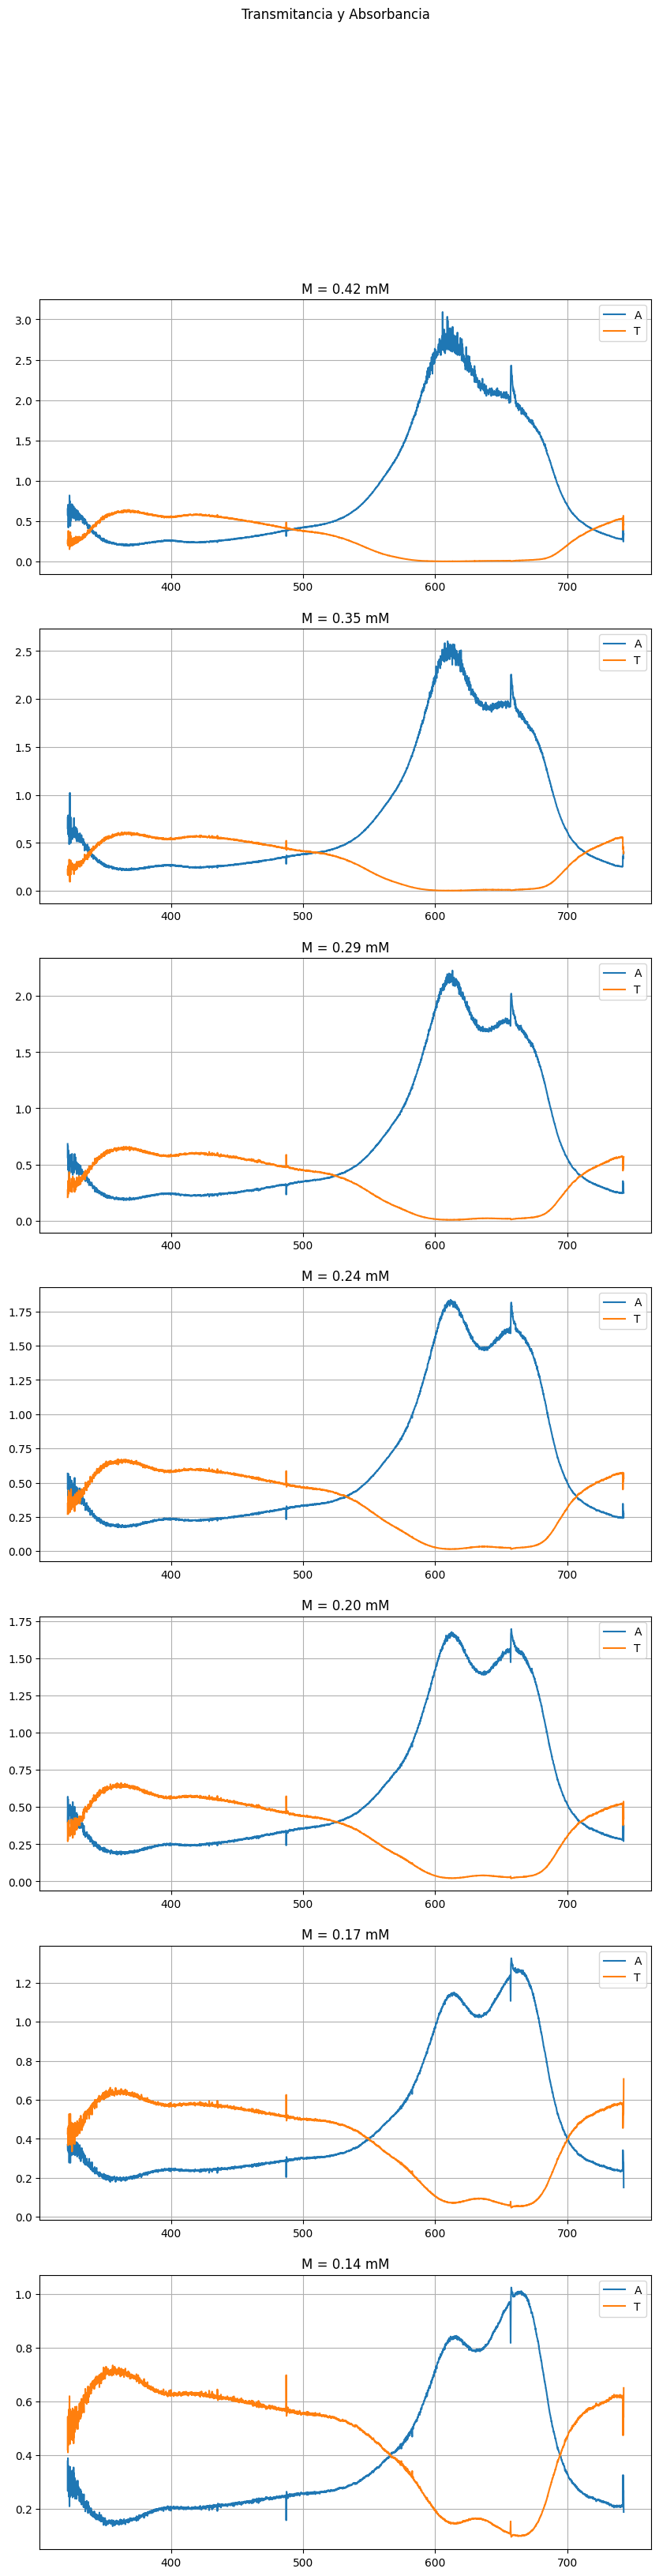

In [62]:
fig, ax = plt.subplots(7,1,figsize=(10,37))
fig.suptitle('Transmitancia y Absorbancia')

for i,T in enumerate(Ts):
    ax[i].plot(T['lambda'],T['A'],label='A')
    ax[i].plot(T['lambda'],T['T'],label='T')
    ax[i].set(title=f'M = {concentrations[i]:.2f} mM')
    ax[i].legend()
    ax[i].grid()